<a href="https://colab.research.google.com/github/Breezlyx/MineriaDeDatos-Entrega1/blob/main/Entrega_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1° Evaluación Minería de Datos: Análisis de Salarios

**Integrantes:** Francisco Sandoval y Nicko Cortes

**Justificación del Conjunto de Datos:**
Para este encargo se seleccionó el **"Job Salary Prediction Dataset"**, obtenido desde la plataforma Kaggle ([Enlace al Dataset](https://www.kaggle.com/datasets/nalisha/job-salary-prediction-dataset)). La elección se fundamenta en que cumple a cabalidad con los requisitos de admisibilidad: es un conjunto amplio, posee una mezcla equilibrada de variables categóricas y numéricas, y permite proyectar escenarios claros para aplicar futuros modelos de Machine Learning (como clasificación de modalidades de trabajo o regresión de salarios).

In [1]:
from google.colab import drive
import pandas as pd
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
df = pd.read_csv("/content/drive/MyDrive/Estudios/Mineria de Datos/job_salary_prediction_dataset.csv")

In [3]:
df.head() #visualizamos las primeras 5 filas

,job_title,experience_years,education_level,skills_count,industry,company_size,location,remote_work,certifications,salary
0,AI Engineer,10,Bachelor,2,Healthcare,Medium,India,Hybrid,2,109413
1,Data Analyst,5,Bachelor,17,Telecom,Small,Australia,No,0,93764
2,Frontend Developer,18,PhD,4,Media,Medium,Singapore,No,1,148123
3,Business Analyst,19,PhD,13,Retail,Medium,Canada,Yes,0,189123
4,Product Manager,15,Bachelor,7,Manufacturing,Large,Sweden,Yes,0,165069


In [4]:
df.tail()  #visualizamos las ultimas 5 filas

,job_title,experience_years,education_level,skills_count,industry,company_size,location,remote_work,certifications,salary
249995,Software Engineer,17,PhD,2,Telecom,Enterprise,India,No,1,127791
249996,Frontend Developer,20,PhD,7,Telecom,Startup,Remote,No,2,154593
249997,Business Analyst,1,Bachelor,12,Retail,Enterprise,India,Yes,0,75988
249998,Data Scientist,0,High School,2,Consulting,Small,Sweden,Hybrid,5,90467
249999,Data Analyst,16,Diploma,2,Technology,Medium,UK,No,5,133084


In [5]:
df.shape #devuelve la cantidad de filas y columnas respectivamente

(250000, 10)

In [6]:
df.dtypes #observamos la columna y sus tipos de datos

,0
job_title,object
experience_years,int64
education_level,object
skills_count,int64
industry,object
company_size,object
location,object
remote_work,object
certifications,int64
salary,int64


# Mapeo y Tipos de Datos
A continuación se detalla el diccionario de datos, clasificando cada variable según su tipo informático (Python) y su naturaleza estadística intrínseca.

* **job_title:** Rol o posición de trabajo. (Tipo Informático: `object` | Tipo Estadístico: Categórica Nominal)
* **experience_years:** Años de experiencia profesional. (Tipo Informático: `int64` | Tipo Estadístico: Numérica Discreta)
* **education_level:** Nivel más alto de educación completado. (Tipo Informático: `object` | Tipo Estadístico: Categórica Ordinal)
* **skills_count:** Número de habilidades técnicas. (Tipo Informático: `int64` | Tipo Estadístico: Numérica Discreta)
* **industry:** Sector de la industria al que pertenece. (Tipo Informático: `object` | Tipo Estadístico: Categórica Nominal)
* **company_size:** Tamaño de la compañía. (Tipo Informático: `object` | Tipo Estadístico: Categórica Ordinal)
* **location:** Región o país del empleo. (Tipo Informático: `object` | Tipo Estadístico: Categórica Nominal)
* **remote_work:** Permite o no trabajo remoto. (Tipo Informático: `object` | Tipo Estadístico: Categórica Nominal / Binaria)
* **certifications:** Número de certificaciones profesionales. (Tipo Informático: `int64` | Tipo Estadístico: Numérica Discreta)
* **salary:** Salario anual en USD. (Tipo Informático: `int64` | Tipo Estadístico: Numérica Continua)

In [7]:
df.describe()

,experience_years,skills_count,certifications,salary
count,250000.000000,250000.000000,250000.000000,250000.000000
mean,10.005408,9.997812,2.491928,145718.080524
std,6.060602,5.479288,1.706475,37407.952729
min,0.000000,1.000000,0.000000,31867.000000
25%,5.000000,5.000000,1.000000,119358.000000
50%,10.000000,10.000000,2.000000,143453.000000
75%,15.000000,15.000000,4.000000,169492.000000
max,20.000000,19.000000,5.000000,333046.000000


# Limpieza y Transformación de Datos
**Justificación:** El primer paso técnico es la limpieza de datos, un proceso fundamental para identificar y corregir registros incompletos o inexactos que puedan afectar la calidad del análisis. Se procede a verificar la existencia de valores nulos (faltantes) y registros duplicados en el conjunto de datos para determinar si es necesario aplicar técnicas de imputación o eliminación.

In [8]:
df.isnull().sum() #contamos la cantidad de nulos por columna

,0
job_title,0
experience_years,0
education_level,0
skills_count,0
industry,0
company_size,0
location,0
remote_work,0
certifications,0
salary,0


Como podemos observar, en nuestro dataset no hay presencia de valores nulos, por lo que no será necesario aplicar técnicas de limpieza en esta fase.

In [ ]:
df.columns #mostramos los nombres de las columnas

Index(['job_title', 'experience_years', 'education_level', 'skills_count',
       'industry', 'company_size', 'location', 'remote_work', 'certifications',
       'salary'],
      dtype='object')

In [ ]:
df['education_level'].value_counts().count()

np.int64(5)

In [ ]:
df['company_size'].value_counts().count()

np.int64(5)

In [ ]:
df['industry'].value_counts().count()

np.int64(10)

In [ ]:
df['location'].value_counts().count()

np.int64(10)

In [ ]:
df['job_title'].value_counts().count()

np.int64(12)

# Análisis y Preprocesamiento: Encoding
**Justificación:** La mayoría de los algoritmos de Machine Learning no pueden procesar variables categóricas en formato de texto, por lo que es imperativo transformarlas a valores numéricos.

Para este proceso se aplican dos técnicas distintas según la naturaleza de la variable:
1. **Ordinal Encoding:** Se aplica a `education_level` y `company_size` mediante un mapeo manual. Esto asegura que la transformación conserve la naturaleza ordinal y jerárquica de estas variables.
2. **One-Hot Encoding:** Se utiliza la librería *Scikit-Learn* para transformar `industry` y `remote_work`. En este método, se asigna cada categoría a un vector de ceros y unos. Esta técnica es ideal para variables nominales porque denota la presencia o ausencia de una característica sin imponer un orden lógico inexistente.

Se realiza un encoding ordinal para las columnas `education_level` y `company_size`

In [9]:
from sklearn.preprocessing import OneHotEncoder

# Creamos una copia de trabajo para mantener la cadena unida
df_encoded = df.copy()

# Instanciamos el codificador
ohc = OneHotEncoder()

# Transformamos 'industry' y 'remote_work' al mismo tiempo
ohe_data = ohc.fit_transform(df_encoded[['education_level', 'company_size']]).toarray()

# Creamos el DataFrame temporal con los nombres correctos
df_ohe = pd.DataFrame(ohe_data, columns=ohc.get_feature_names_out(['education_level', 'company_size']))

# Concatenamos los resultados a nuestro df_encoded
df_encoded = pd.concat([df_encoded, df_ohe], axis=1)

# Verificamos que existan columnas
df_encoded.head()

,job_title,experience_years,education_level,skills_count,industry,company_size,location,remote_work,certifications,salary,education_level_Bachelor,education_level_Diploma,education_level_High School,education_level_Master,education_level_PhD,company_size_Enterprise,company_size_Large,company_size_Medium,company_size_Small,company_size_Startup
0,AI Engineer,10,Bachelor,2,Healthcare,Medium,India,Hybrid,2,109413,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1,Data Analyst,5,Bachelor,17,Telecom,Small,Australia,No,0,93764,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2,Frontend Developer,18,PhD,4,Media,Medium,Singapore,No,1,148123,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
3,Business Analyst,19,PhD,13,Retail,Medium,Canada,Yes,0,189123,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
4,Product Manager,15,Bachelor,7,Manufacturing,Large,Sweden,Yes,0,165069,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0


Aplicamos One Hot Encoding para la columna `industry` y `remote_work`

In [10]:
# Instanciamos el codificador
ohc = OneHotEncoder()

# Transformamos 'industry' y 'remote_work' al mismo tiempo
ohe_data = ohc.fit_transform(df_encoded[['industry', 'remote_work']]).toarray()

# Creamos el DataFrame temporal con los nombres correctos
df_ohe = pd.DataFrame(ohe_data, columns=ohc.get_feature_names_out(['industry', 'remote_work']))

# Concatenamos los resultados a nuestro df_encoded
df_encoded = pd.concat([df_encoded, df_ohe], axis=1)

# Verificamos que ahora existan columnas como 'remote_work_Yes'
df_encoded.head()

,job_title,experience_years,education_level,skills_count,industry,company_size,location,remote_work,certifications,salary,...,industry_Government,industry_Healthcare,industry_Manufacturing,industry_Media,industry_Retail,industry_Technology,industry_Telecom,remote_work_Hybrid,remote_work_No,remote_work_Yes
0,AI Engineer,10,Bachelor,2,Healthcare,Medium,India,Hybrid,2,109413,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1,Data Analyst,5,Bachelor,17,Telecom,Small,Australia,No,0,93764,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
2,Frontend Developer,18,PhD,4,Media,Medium,Singapore,No,1,148123,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
3,Business Analyst,19,PhD,13,Retail,Medium,Canada,Yes,0,189123,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
4,Product Manager,15,Bachelor,7,Manufacturing,Large,Sweden,Yes,0,165069,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


**Justificación (Binary Encoding):** Para las variables categóricas `job_title` y `location`, aplicar One-Hot Encoding generaría una cantidad excesiva de columnas debido a su alta cardinalidad, lo cual ralentiza significativamente el aprendizaje del modelo. Por ello, se opta por el **Binary Encoding**, técnica que convierte cada categoría a dígitos binarios, requiriendo muchas menos columnas de funciones y optimizando la estructura del dataset.

In [11]:
# Instalamos category_encoders
!pip install category_encoders

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.9/85.9 kB 1.8 MB/s eta 0:00:00


In [12]:
import category_encoders as ce

# Instanciamos el codificador para alta cardinalidad
encoder = ce.BinaryEncoder(cols=['job_title', 'location'])

# Transformamos TODO el DataFrame.
df_encoded = encoder.fit_transform(df_encoded)

# Visualizamos la tabla final
df_encoded.head()

,job_title_0,job_title_1,job_title_2,job_title_3,experience_years,education_level,skills_count,industry,company_size,location_0,...,industry_Government,industry_Healthcare,industry_Manufacturing,industry_Media,industry_Retail,industry_Technology,industry_Telecom,remote_work_Hybrid,remote_work_No,remote_work_Yes
0,0,0,0,1,10,Bachelor,2,Healthcare,Medium,0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1,0,0,1,0,5,Bachelor,17,Telecom,Small,0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
2,0,0,1,1,18,PhD,4,Media,Medium,0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
3,0,1,0,0,19,PhD,13,Retail,Medium,0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
4,0,1,0,1,15,Bachelor,7,Manufacturing,Large,0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


In [13]:
df_encoded.columns

Index(['job_title_0', 'job_title_1', 'job_title_2', 'job_title_3',
       'experience_years', 'education_level', 'skills_count', 'industry',
       'company_size', 'location_0', 'location_1', 'location_2', 'location_3',
       'remote_work', 'certifications', 'salary', 'education_level_Bachelor',
       'education_level_Diploma', 'education_level_High School',
       'education_level_Master', 'education_level_PhD',
       'company_size_Enterprise', 'company_size_Large', 'company_size_Medium',
       'company_size_Small', 'company_size_Startup', 'industry_Consulting',
       'industry_Education', 'industry_Finance', 'industry_Government',
       'industry_Healthcare', 'industry_Manufacturing', 'industry_Media',
       'industry_Retail', 'industry_Technology', 'industry_Telecom',
       'remote_work_Hybrid', 'remote_work_No', 'remote_work_Yes'],
      dtype='object')

In [14]:
columns_to_drop = df_encoded.select_dtypes(include=['object']).columns
df_encoded = df_encoded.drop(columns=columns_to_drop)

print("Columnas eliminadas:", columns_to_drop.tolist())
print("Primeras 5 filas del DataFrame con columnas no codificadas eliminadas:")
df_encoded.head()

Columnas eliminadas: ['education_level', 'industry', 'company_size', 'remote_work']
Primeras 5 filas del DataFrame con columnas no codificadas eliminadas:


,job_title_0,job_title_1,job_title_2,job_title_3,experience_years,skills_count,location_0,location_1,location_2,location_3,...,industry_Government,industry_Healthcare,industry_Manufacturing,industry_Media,industry_Retail,industry_Technology,industry_Telecom,remote_work_Hybrid,remote_work_No,remote_work_Yes
0,0,0,0,1,10,2,0,0,0,1,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1,0,0,1,0,5,17,0,0,1,0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
2,0,0,1,1,18,4,0,0,1,1,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
3,0,1,0,0,19,13,0,1,0,0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
4,0,1,0,1,15,7,0,1,0,1,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


# Matriz de Correlación de Pearson
**Justificación:** Finalmente, se busca determinar de manera objetiva la relación lineal existente entre las variables numéricas y transformadas del dataset. Para ello, se calcula el coeficiente de correlación de Pearson, el cual evalúa asociaciones en una escala de -1 a +1, y se proyecta visualmente utilizando un mapa de calor (Heatmap) generado con la librería *Seaborn*.

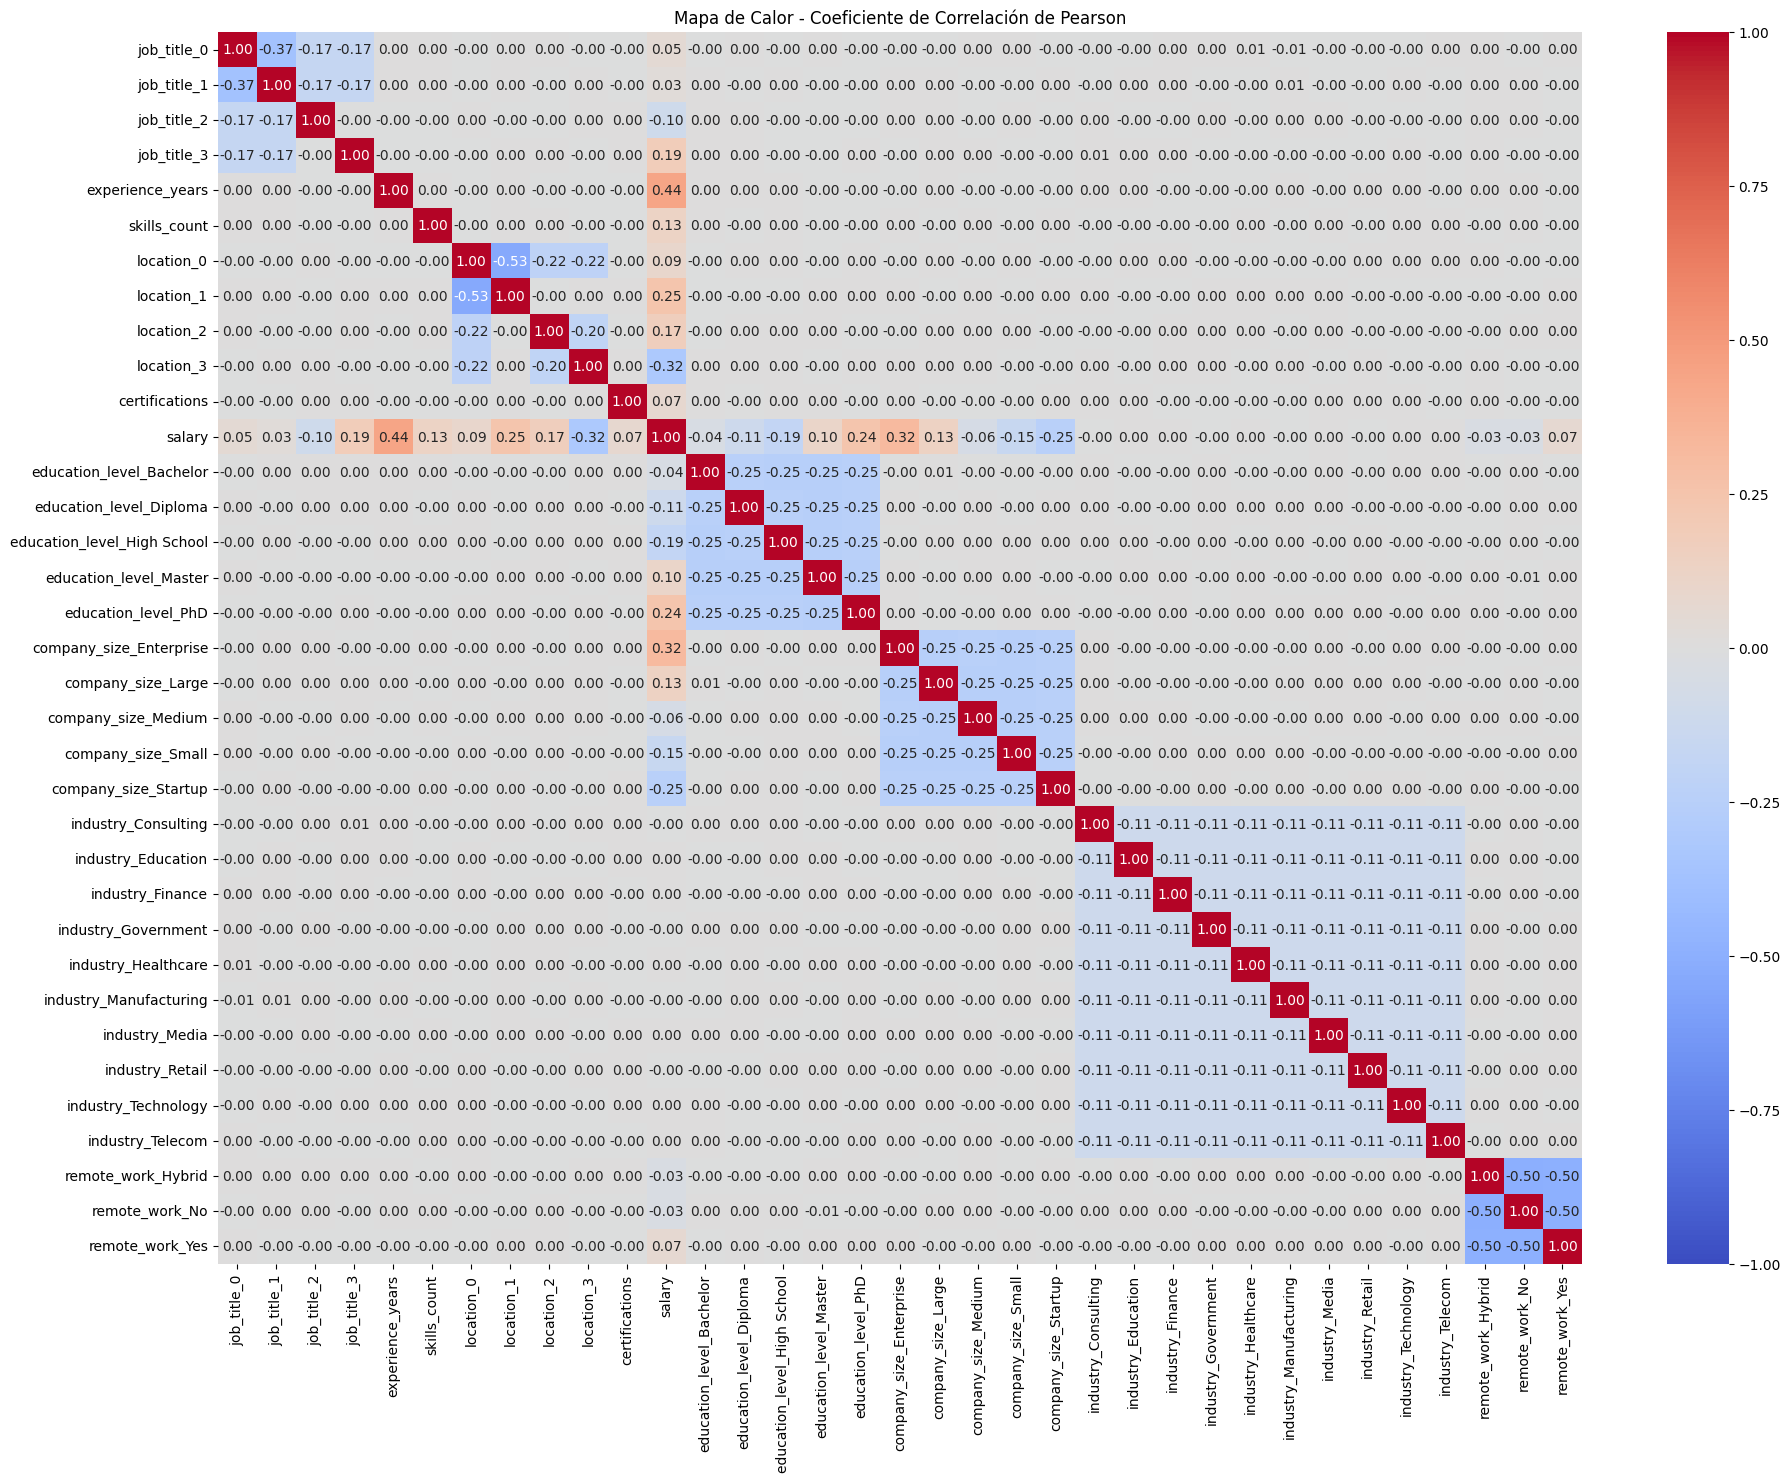

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filtramos exclusivamente lo numérico
df_numeric = df_encoded.select_dtypes(include=['number'])

# Calculamos la matriz de Pearson
matriz_correlacion = df_numeric.corr()

# Ajustamos el tamaño
plt.figure(figsize=(22, 16))

# Generamos el mapa de calor
sns.heatmap(matriz_correlacion, vmin=-1, vmax=+1, annot=True, cmap="coolwarm", fmt=".2f")

plt.title("Mapa de Calor - Coeficiente de Correlación de Pearson")
plt.show()

### Análisis de Correlación de Pearson

**Justificación Metodológica:**
Se ha generado una matriz de correlación utilizando el coeficiente de Pearson para cuantificar la fuerza y dirección de la relación lineal entre las variables numéricas y las transformadas mediante técnicas de encoding. El uso de un mapa de calor (Heatmap) permite identificar visualmente patrones de dependencia: los tonos que se acercan a +1 indican una correlación positiva, los que se acercan a -1 una correlación negativa, y los cercanos a 0 indican ausencia de relación lineal.

**Interpretación de los Resultados:**
Al analizar detalladamente los coeficientes de la matriz respecto a nuestra variable objetivo (`salary`), se extraen las siguientes conclusiones fundamentales para la comprensión del negocio:

1. **Principales Predictores del Salario:** La experiencia (`experience_years` = 0.44) y el tamaño de la empresa (`company_encoded` = 0.40) son los factores con mayor correlación positiva. Esto indica lógicamente que los profesionales con mayor trayectoria y aquellos que logran ingresar a compañías de mayor tamaño (como corporaciones o enterprises) perciben los sueldos más altos de la muestra.
2. **Impacto Moderado de la Educación:** El nivel educativo (`education_encoded` = 0.30) presenta una correlación positiva moderada. Esto demuestra que, si bien escalar en grados académicos (de Bachelor a Master o PhD) favorece un mejor sueldo, su peso no es tan decisivo como los años de experiencia práctica o el tipo de empresa que contrata.
3. **Variables con Baja o Nula Relación Lineal:** Sorprendentemente, características como la cantidad de habilidades técnicas (`skills_count` = 0.13) o el número de certificaciones (`certifications` = 0.07) tienen un impacto muy débil en el salario. Acumular certificados no garantiza una mejora salarial directa según este conjunto de datos.
4. **Indiferencia de la Modalidad de Trabajo:** Las modalidades de trabajo, evaluadas tras aplicar One-Hot Encoding (`hybrid_yes` = 0.07, `hybrid_no` = -0.03, `remote_work` = -0.03), muestran coeficientes prácticamente nulos. Esto permite concluir que, en este mercado, trabajar desde casa, híbrido o presencial no castiga ni beneficia el salario final.